In [47]:

import sys
sys.path.append("../scripts")

import numpy as np
from pathlib import Path
import torch
from scipy.special import log_softmax
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from metrics_scatter_plots import compute_sample_metric, DATASETS


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


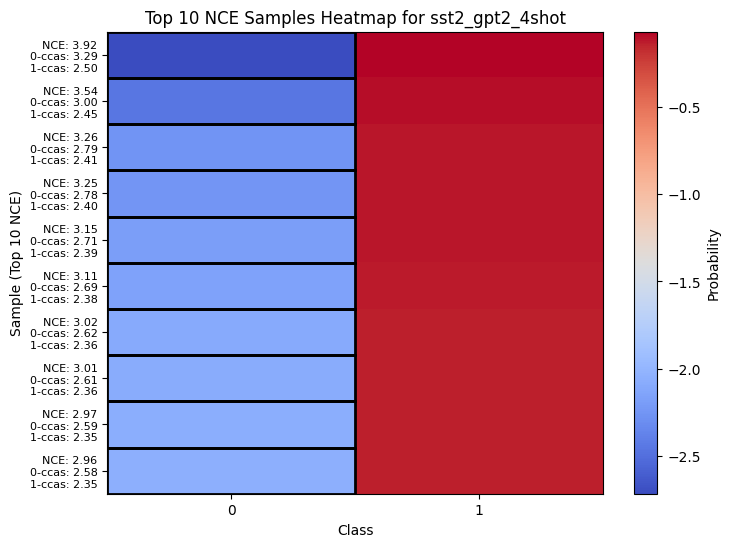

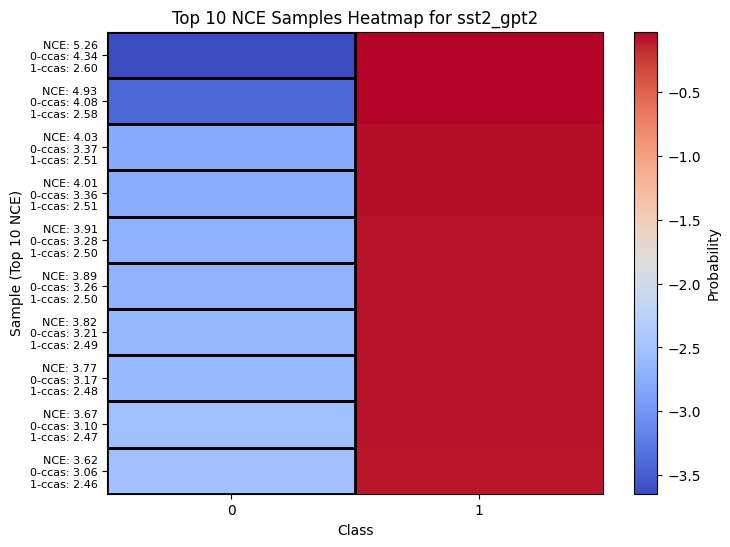

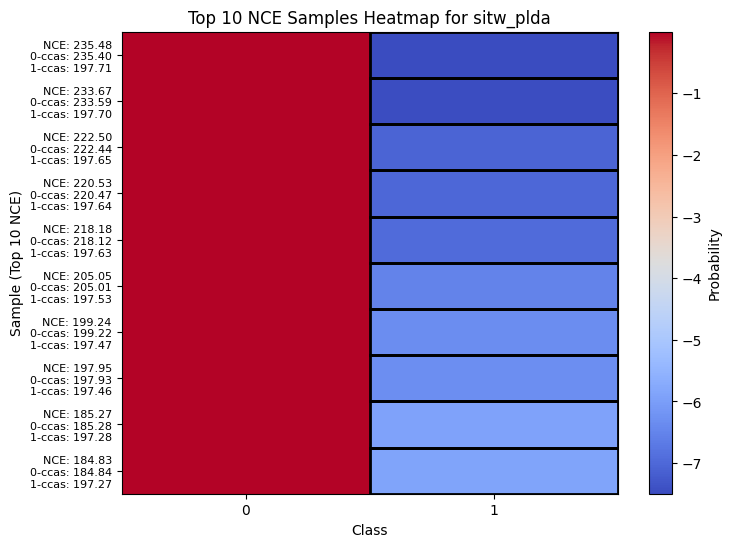

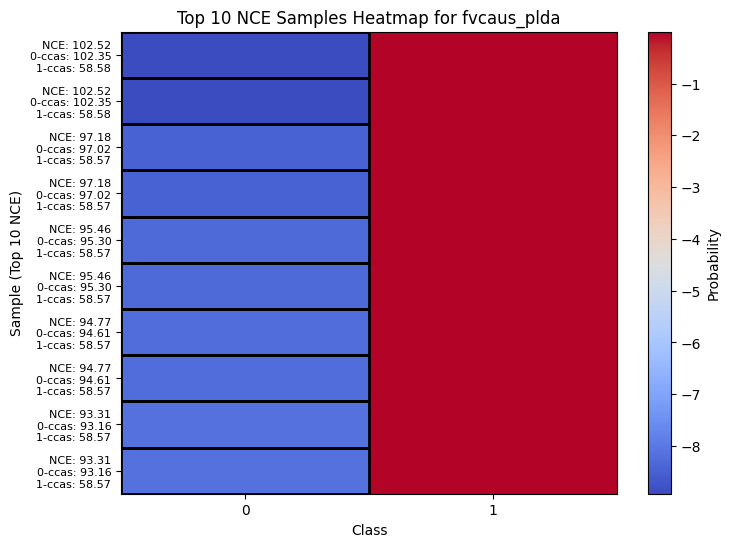

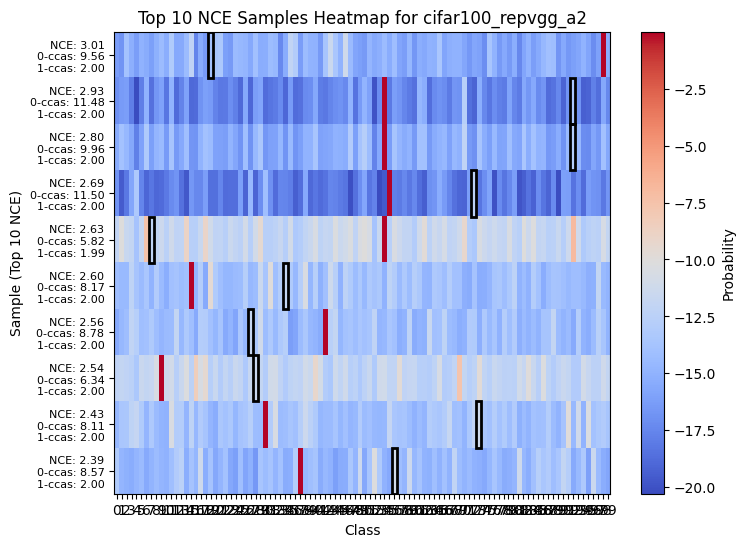

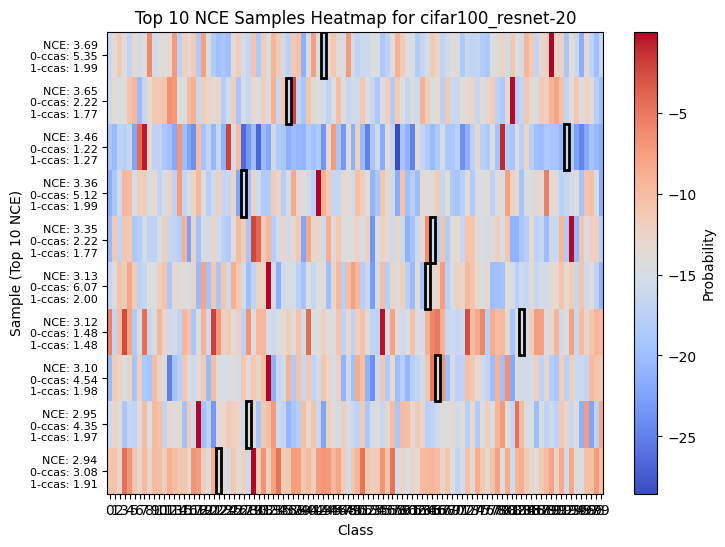

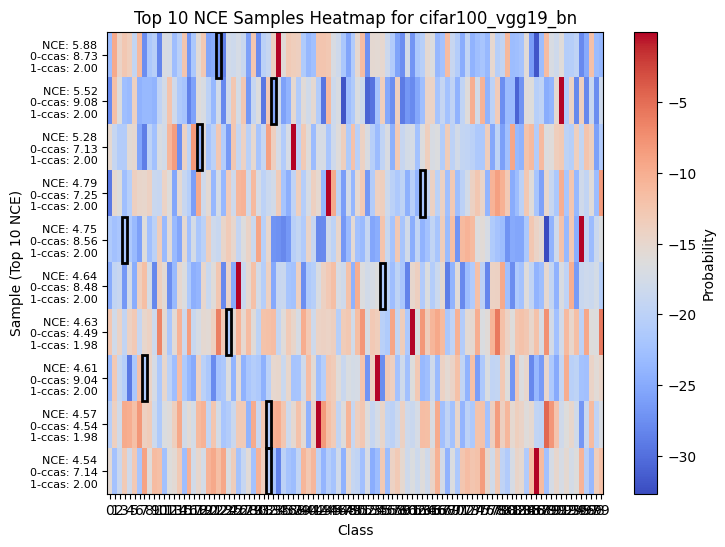

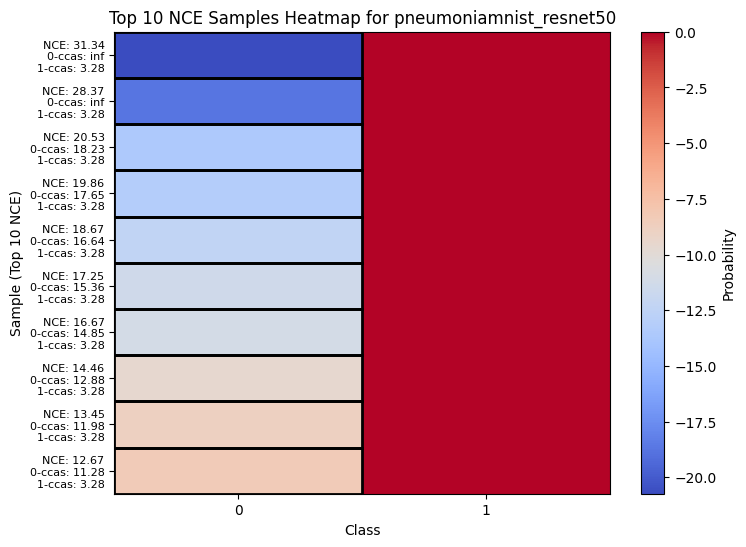

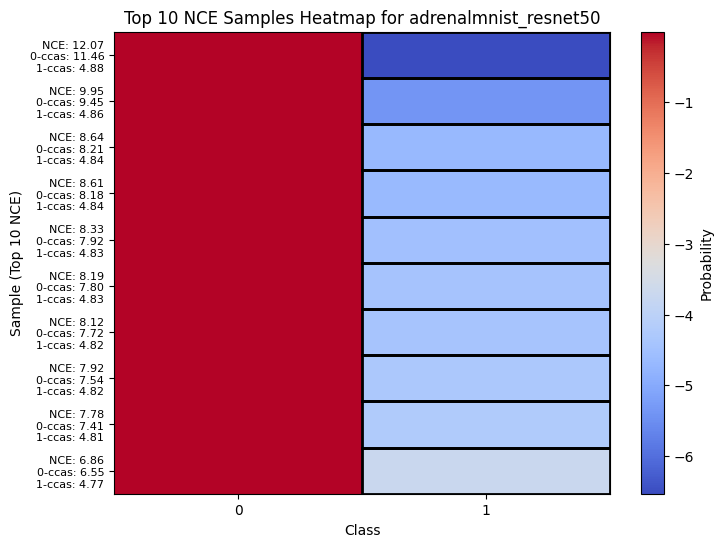

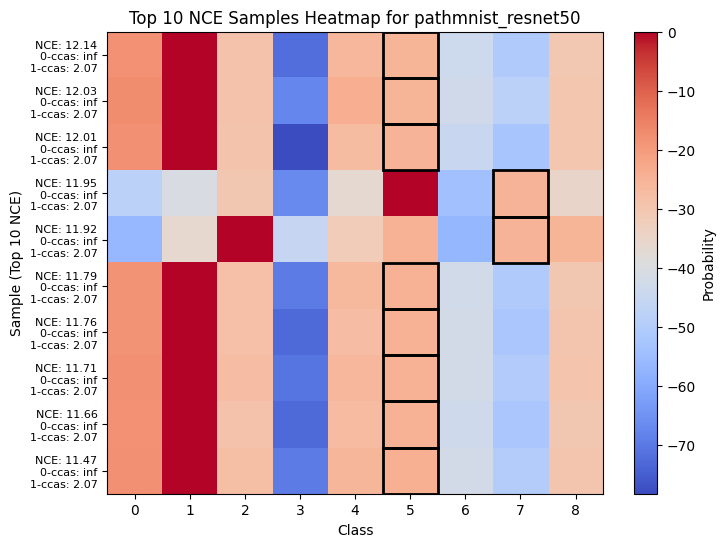

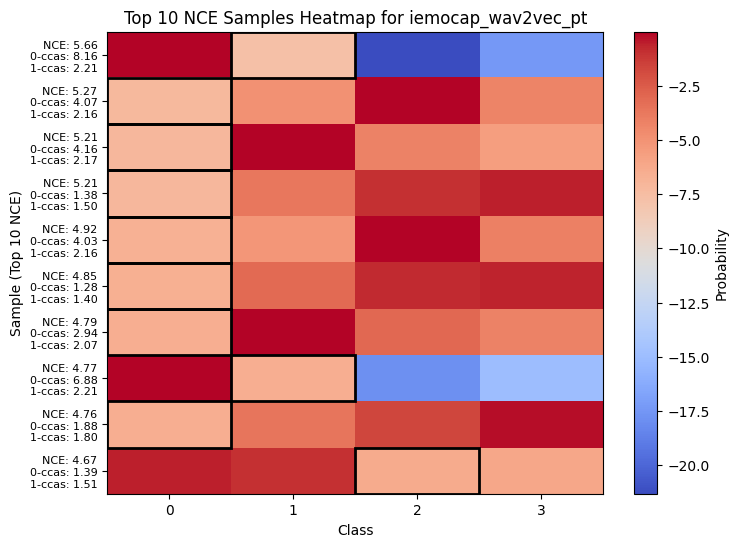

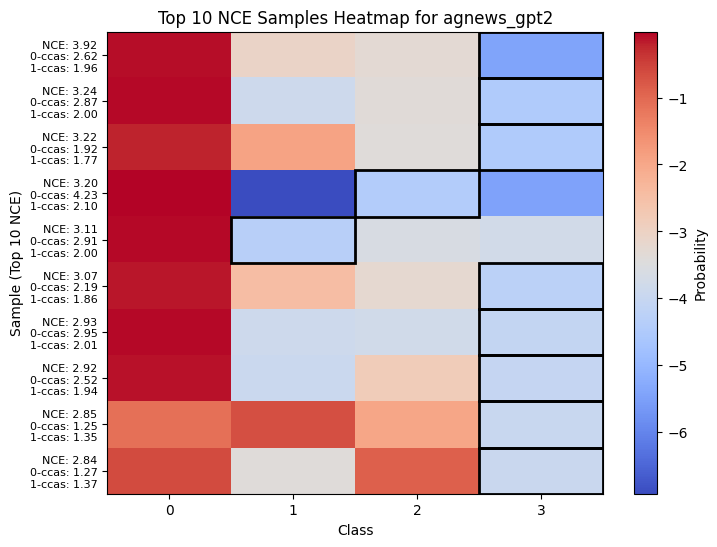

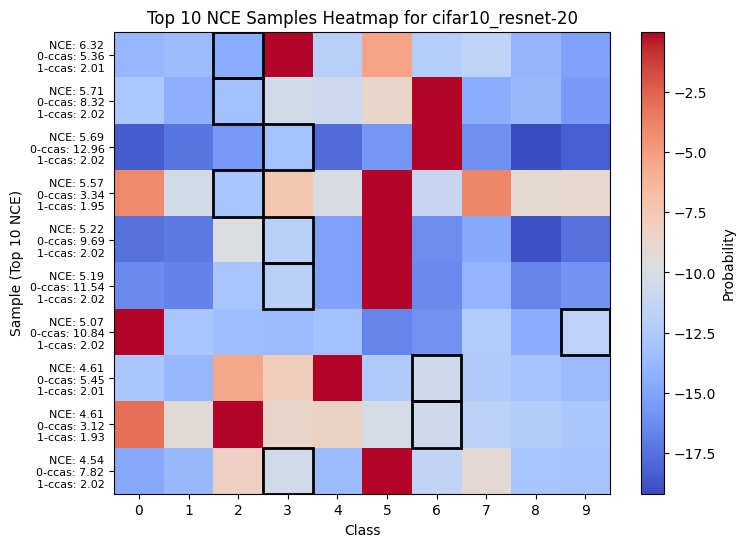

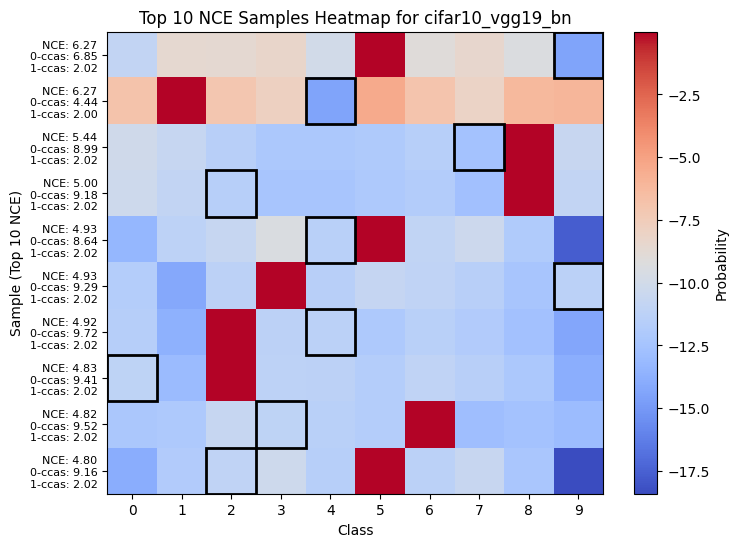

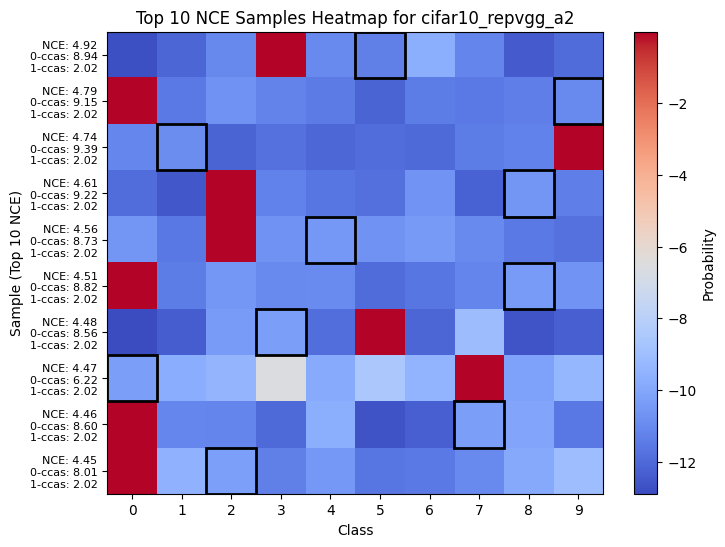

In [48]:
for dataset_model in DATASETS:
    data_path = Path("../scores/classification") / dataset_model
    logprobs = torch.from_numpy(log_softmax(np.load(data_path / "scores.npy"), axis=1)).float()
    labels = torch.from_numpy(np.load(data_path / "targets.npy").reshape(-1))
    logpriors = torch.log(torch.bincount(labels.long(), minlength=logprobs.size(1)).float() / labels.size(0)).unsqueeze(0).expand(logprobs.size(0), -1)
    nce_results = compute_sample_metric(logprobs, labels, "cross_entropy", logpriors)
    nce_high_idx = np.argsort(nce_results)[-10:][::-1].copy()
    c0ccas_results = compute_sample_metric(logprobs, labels, "0-ccas", logpriors)
    c1ccas_results = compute_sample_metric(logprobs, labels, "1-ccas", logpriors)
    probs = torch.exp(logprobs).numpy()

    # Select the top k samples and their data
    selected_probs = logprobs.numpy()[nce_high_idx]
    selected_labels = labels[nce_high_idx].numpy()

    fig, ax = plt.subplots(figsize=(8, 6))
    # warm cold cmap
    im = ax.imshow(selected_probs, aspect='auto', cmap="coolwarm")

    # Draw a rectangle around the correct label for each sample
    for i, label in enumerate(selected_labels):
        rect = patches.Rectangle((label - 0.5, i - 0.5), 1, 1, linewidth=2, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

    ax.set_xlabel('Class')
    ax.set_xticks(np.arange(probs.shape[1]))
    ax.set_ylabel('Sample (Top 10 NCE)')
    ax.set_yticks(np.arange(len(nce_high_idx)), labels=[f"NCE: {nce_results[idx]:.2f}\n0-ccas: {c0ccas_results[idx]:.2f}\n1-ccas: {c1ccas_results[idx]:.2f}" for idx in nce_high_idx], fontsize=8)
    ax.set_title(f'Top 10 NCE Samples Heatmap for {dataset_model}')
    fig.colorbar(im, ax=ax, label='Probability')
    plt.show()